# 02 - Early Exploration

Goal: build actual intuition for what's in this dataset before going into
`03_feature_engineering.ipynb` -- trajectory lengths, geographic spread, and
how active-fire extent evolves over time by severity class. Feature-level
exploration (distributions, correlations, separation by severity_class,
clustering) lives in `04_feature_diagnostics.ipynb`, once early features exist.


In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from flashpoint.db import get_connection

DB_PATH = Path("../data/flashpoint.duckdb")
con = get_connection(DB_PATH)

events_df = con.execute("SELECT * FROM events").df()
outcomes_df = con.execute("SELECT * FROM event_outcomes").df()
full_df = con.execute("""
    SELECT e.year, e.centroid_lon, e.centroid_lat, e.n_days, o.max_area_ha, o.severity_class
    FROM events e
    JOIN event_outcomes o ON o.event_id = e.event_id
""").df()
print(f"{len(events_df)} events total, {len(full_df)} with outcomes")


607 events total, 607 with outcomes


## Step 1: What's a "typical" fire trajectory?

`n_days` includes the 4 buffer days added before and after each fire's
official GlobFire dates (per the paper), so this is somewhat longer than
the fire's actual active duration -- but still the right number to look at
for "how many days of data does a typical event give us."

count    607.000000
mean      22.416804
std       10.724540
min        9.000000
25%       15.000000
50%       19.000000
75%       26.000000
max       94.000000
Name: n_days, dtype: float64


Text(0.5, 1.0, 'Fire trajectory length')

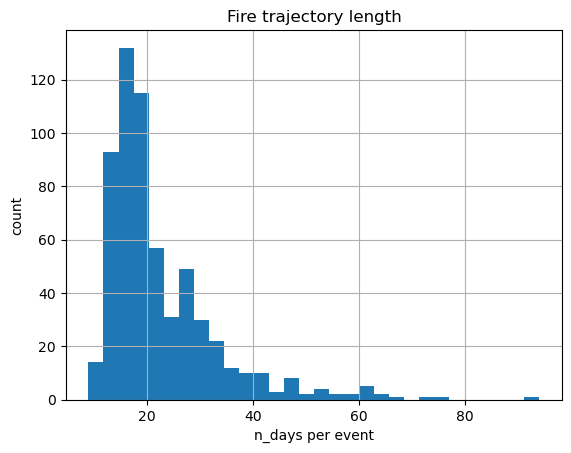

In [2]:
print(events_df['n_days'].describe())
events_df['n_days'].hist(bins=30)
plt.xlabel('n_days per event')
plt.ylabel('count')
plt.title('Fire trajectory length')

## Step 2: Events per year, and where they are geographically

2019 is the known outlier year (paper reports 74 fires vs. 150-200 in
other years) -- worth seeing that directly rather than just taking it on
faith.

year
2018    176
2019     74
2020    201
2021    156
Name: count, dtype: int64


/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


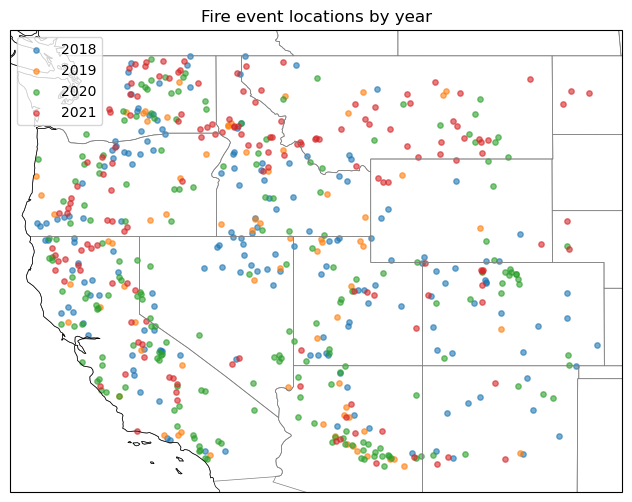

In [3]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print(events_df['year'].value_counts().sort_index())

extent = [
    events_df['centroid_lon'].min() - 1, events_df['centroid_lon'].max() + 1,
    events_df['centroid_lat'].min() - 1, events_df['centroid_lat'].max() + 1,
]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent(extent, crs=ccrs.PlateCarree())

for year, group in events_df.groupby('year'):
    ax.scatter(group['centroid_lon'], group['centroid_lat'], label=str(year),
               alpha=0.6, s=15, transform=ccrs.PlateCarree())
ax.set_title('Fire event locations by year')
ax.legend()

## Step 3: Does geography relate to severity?

Same scatter, colored by severity_class instead of year -- worth checking
whether big fires cluster in particular regions (which would suggest
location/terrain matters more than day-1/day-2 weather alone).

/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/pmacias/opt/anaconda3/envs/flashpoint/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


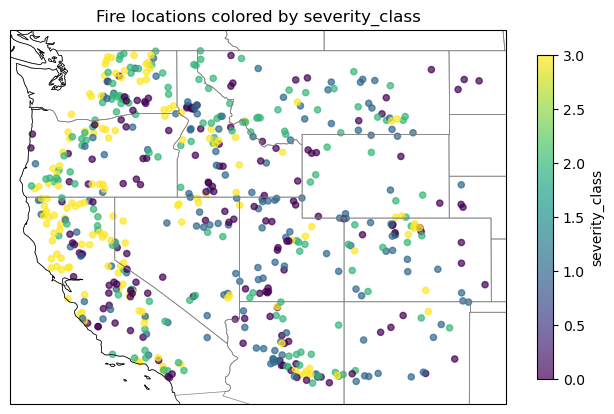

In [4]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent(extent, crs=ccrs.PlateCarree())

sc = ax.scatter(full_df['centroid_lon'], full_df['centroid_lat'],
                 c=full_df['severity_class'], cmap='viridis', alpha=0.7, s=20,
                 transform=ccrs.PlateCarree())
ax.set_title('Fire locations colored by severity_class')
plt.colorbar(sc, label='severity_class', ax=ax, shrink=0.7)

## Step 4: Actual fire trajectories over time

Active-fire extent per day, for a sample of events stratified by severity
class -- do severe fires spike early and stay high, ignite late, or
oscillate, versus small/contained ones staying flat near zero throughout?

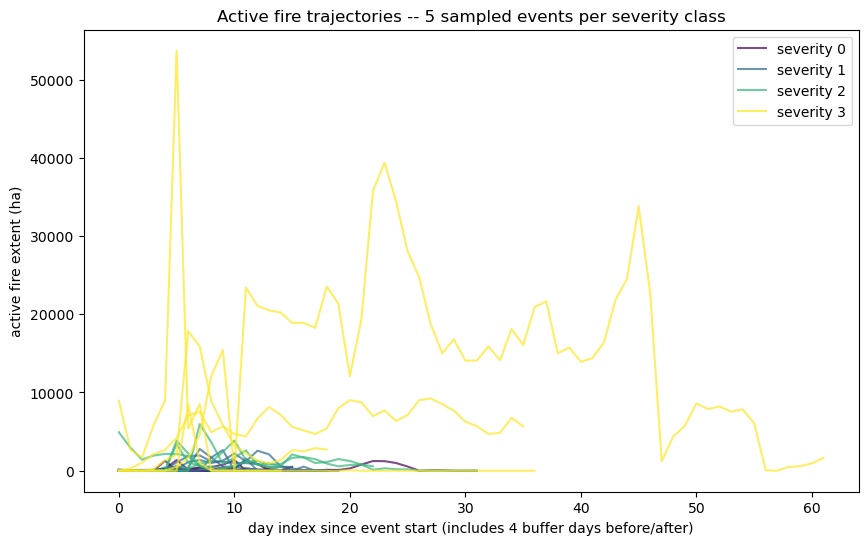

In [5]:
import numpy as np
from flashpoint.data_access import HDF5Event, read_channel_all_days, ACTIVE_FIRE_CHANNEL_IDX, PIXEL_AREA_HA

N_PER_CLASS = 5  # bump up for more lines, or set to None below to plot everything

plot_df = con.execute("""
    SELECT e.event_id, e.hdf5_path, e.n_days, o.severity_class
    FROM events e JOIN event_outcomes o ON o.event_id = e.event_id
    WHERE o.severity_class IS NOT NULL
""").df()

sample_df = pd.concat([
    g.sample(min(N_PER_CLASS, len(g)), random_state=0)
    for _, g in plot_df.groupby('severity_class')
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.viridis
seen_classes = set()

for _, row in sample_df.iterrows():
    event = HDF5Event(
        event_id=row['event_id'], year=0, hdf5_path=Path(row['hdf5_path']),
        n_days=row['n_days'], img_dates=[], lnglat=(0, 0),
    )
    af_all_days = read_channel_all_days(event, ACTIVE_FIRE_CHANNEL_IDX)
    area_per_day = (af_all_days > 0).reshape(af_all_days.shape[0], -1).sum(axis=1) * PIXEL_AREA_HA

    cls = row['severity_class']
    label = f"severity {cls}" if cls not in seen_classes else None
    seen_classes.add(cls)
    ax.plot(range(len(area_per_day)), area_per_day,
            color=cmap(cls / plot_df['severity_class'].max()), alpha=0.7, label=label)

ax.set_xlabel('day index since event start (includes 4 buffer days before/after)')
ax.set_ylabel('active fire extent (ha)')
ax.set_title(f'Active fire trajectories -- {N_PER_CLASS} sampled events per severity class')
ax.legend()

## Step 5: Same trajectories, split into 4 panels with independent y-axes

A shared y-axis buries small/contained fires under the largest ones --
one panel per severity class, each auto-scaled to its own data, shows
the shape of each tier properly.

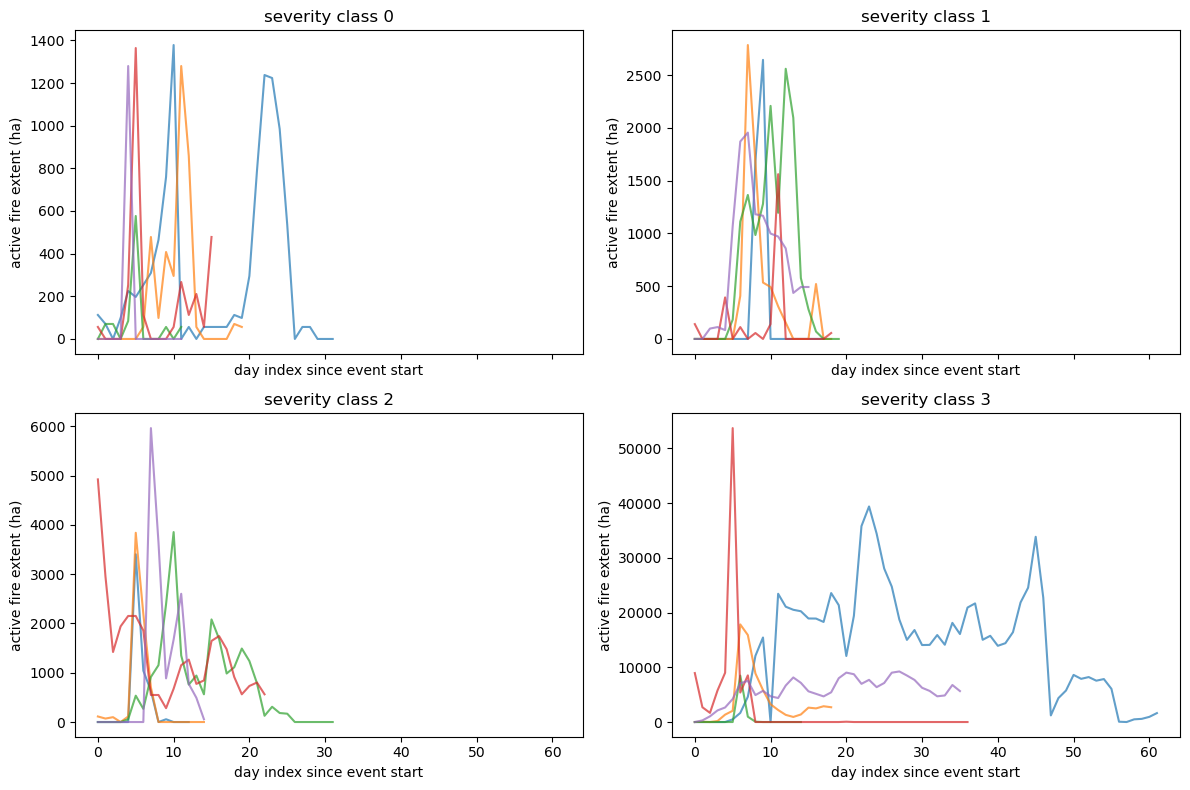

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for cls in sorted(plot_df['severity_class'].unique()):
    ax = axes[cls]
    class_events = plot_df[plot_df['severity_class'] == cls]
    sample = class_events.sample(min(N_PER_CLASS, len(class_events)), random_state=0)

    for _, row in sample.iterrows():
        event = HDF5Event(
            event_id=row['event_id'], year=0, hdf5_path=Path(row['hdf5_path']),
            n_days=row['n_days'], img_dates=[], lnglat=(0, 0),
        )
        af_all_days = read_channel_all_days(event, ACTIVE_FIRE_CHANNEL_IDX)
        area_per_day = (af_all_days > 0).reshape(af_all_days.shape[0], -1).sum(axis=1) * PIXEL_AREA_HA
        ax.plot(range(len(area_per_day)), area_per_day, alpha=0.7)

    ax.set_title(f'severity class {cls}')
    ax.set_xlabel('day index since event start')
    ax.set_ylabel('active fire extent (ha)')

plt.tight_layout()

## Step 6: Takeaways

- Typical trajectory length: ?
- Is 2019 geographically different, or just smaller/fewer fires in the same places?


In [7]:
con.close()